In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# =======================================
# IMPORTS
# =======================================
import os
import numpy as np
import random
import math
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, ImageEnhance
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Flatten, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import VGG16
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight

In [4]:
# ==========================================
# PATHS
# ==========================================
train_dir = '/content/drive/MyDrive/Final_Hybrid_Dataset/Training'
val_dir = '/content/drive/MyDrive/Final_Hybrid_Dataset/Validation'
test_dir = '/content/drive/MyDrive/Final_Hybrid_Dataset/Testing/'

IMAGE_SIZE = 128
BATCH_SIZE = 32
EPOCHS = 10

In [5]:
# ==========================================
# LOAD DATA
# ==========================================
import os
import numpy as np
import random
from sklearn.utils import shuffle

def load_data(data_dir):
  paths = []
  labels = []

  for label in os.listdir(data_dir):
    label_path = os.path.join(data_dir, label)

    if os.path.isdir(label_path):
      for image in os.listdir(label_path):
        paths.append(os.path.join(label_path, image))
        labels.append(label)
  return shuffle(paths, labels)

train_paths, train_labels = load_data(train_dir)
val_paths, val_labels = load_data(val_dir)
test_paths, test_labels = load_data(test_dir)

print("Train samples:", len(train_paths))
print("Test samples:", len(test_paths))

Train samples: 7196
Test samples: 2930


In [6]:
# ===============================================
# LABEL ENCODING
# ===============================================
def get_classes(directory):
    return sorted([
        d for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ])

# Get classes ONLY from training folder
unique_labels = get_classes(train_dir)

print("Classes:", unique_labels)

# Create mapping
label_to_int = {label: i for i, label in enumerate(unique_labels)}

# Encode labels
train_labels = np.array([label_to_int[label] for label in train_labels])
val_labels = np.array([label_to_int[label] for label in val_labels])
test_labels = np.array([label_to_int[label] for label in test_labels])

Classes: ['dog_Dental_Disease', 'dog_Dermatitis', 'dog_Healthy', 'dog_Skin_Disease', 'dog_demodicosis', 'dog_ringworm', 'human_glioma', 'human_meningioma', 'human_notumor', 'human_pituitary']


In [7]:
# ===============================================
# VALIDATION SPLIT
# ===============================================
split_idx = int(0.85 * len(train_paths))

val_paths = train_paths[split_idx:]
val_labels = train_labels[split_idx:]

train_paths = train_paths[:split_idx]
train_labels = train_labels[:split_idx]

In [8]:
# ===============================================
# CLASS WEIGHTS (IMPORTANT)
# ===============================================
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(11.325925925925926), 1: np.float64(1.315268817204301), 2: np.float64(1.4561904761904763), 3: np.float64(0.8825396825396825), 4: np.float64(1.2305835010060362), 5: np.float64(0.9224736048265461), 6: np.float64(0.7359807460890493), 7: np.float64(0.7169988276670575), 8: np.float64(0.7522755227552276), 9: np.float64(0.739540507859734)}


In [9]:
# ==================================================
# IMAGE AUGMENTATION
# ==================================================
from PIL import Image, ImageEnhance, UnidentifiedImageError

def augment_image(image):
  image = Image.fromarray(np.uint8(image))


  image = image.rotate(random.choice([0, 90, 180, 270]))
  image = ImageEnhance.Brightness(image).enhance(random.uniform(0.8, 1.2))
  image = ImageEnhance.Contrast(image).enhance(random.uniform(0.8, 1.2))

  return np.array(image) / 255.0

def open_images(paths):
  images = []
  for path in paths:
    try:
      img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
      img = img_to_array(img)
      img = augment_image(img)
      images.append(img)
    except UnidentifiedImageError:
      print(f"Skipping unidentified image: {path}")
      continue
    except Exception as e:
      print(f"Error processing image {path}: {e}")
      continue
  return np.array(images)

In [10]:
# ================================================
# DATA GENERATOR
# ================================================
def data_gen(paths, labels, batch_size=16):
    while True:
        for i in range(0, len(paths), batch_size):
            batch_paths = paths[i:i+batch_size]
            batch_labels = labels[i:i+batch_size]

            images = open_images(batch_paths)

            # sample weights add
            weights = np.array([class_weights[label] for label in batch_labels])

            yield images, np.array(batch_labels), weights

In [11]:
# ================================================
# MODEL (VGG16)
# ================================================
base_model = VGG16(input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3),
                   include_top=False,
                   weights='imagenet')

# Freeze layers
for layer in base_model.layers:
  layer.trainable = False

# Unfreeze last few layers
for layer in base_model.layers[-4:]:
  layer.trainable = True

# Build model
model = Sequential([
    Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3)),
    base_model,
    Flatten(),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(len(unique_labels), activation='softmax')
    ])

model.compile(
    optimizer=Adam(learning_rate=0.00005),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
    )

model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 4, 4, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,764,682 (60.14 MB)

 Trainable params: 8,129,418 (31.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [12]:
# =========================================
# EARLY STOPPING
# =========================================
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
     monitor='val_loss',
     patience=8,
     restore_best_weights=True
     )

In [13]:
# =========================================
# TRAINING
# =========================================
steps = len(train_paths) // BATCH_SIZE
val_steps = len(val_paths) // BATCH_SIZE

history = model.fit(
    data_gen(train_paths, train_labels, BATCH_SIZE),
    steps_per_epoch=steps,
    epochs=EPOCHS,
    validation_data=data_gen(val_paths, val_labels, BATCH_SIZE),
    validation_steps=val_steps,
    callbacks=[early_stop]
)

Epoch 1/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 3314s 17s/step - accuracy: 0.5175 - loss: 1.3683 - val_accuracy: 0.6960 - val_loss: 0.8597
Epoch 2/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 53s 252ms/step - accuracy: 0.6887 - loss: 0.8462 - val_accuracy: 0.7642 - val_loss: 0.6514
Epoch 3/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 82s 431ms/step - accuracy: 0.7342 - loss: 0.7259 - val_accuracy: 0.7680 - val_loss: 0.6151
Epoch 4/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 52s 275ms/step - accuracy: 0.7811 - loss: 0.5865 - val_accuracy: 0.7968 - val_loss: 0.5408
Epoch 5/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 50s 263ms/step - accuracy: 0.7903 - loss: 0.5747 - val_accuracy: 0.8078 - val_loss: 0.5527
Epoch 6/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 48s 253ms/step - accuracy: 0.8141 - loss: 0.5201 - val_accuracy: 0.8263 - val_loss: 0.4748
Epoch 7/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 46s 244ms/step - accuracy: 0.8371 - loss: 0.4377 - val_accuracy: 0.8492 - val_loss: 0.4433
Epoch 8/10
191/191 ━━━━━━━━━━━━━━━━━━━━ 77s 404ms/step - accuracy: 0.8532 - loss: 0

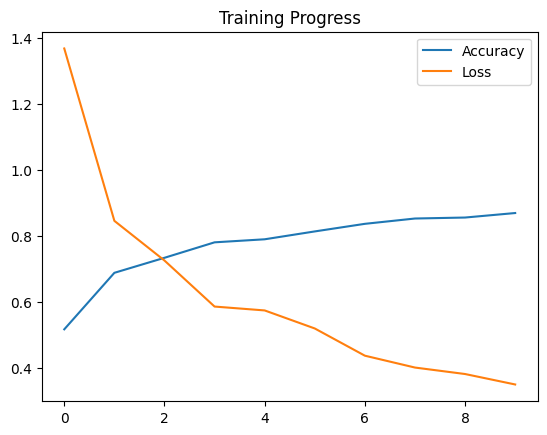

In [14]:
# ============================================
# TRAINING GRAPH
# ============================================
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['loss'], label='Loss')
plt.title('Training Progress')
plt.legend()
plt.show()

In [15]:
# ===========================================
# TESTING
# ===========================================
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from PIL import UnidentifiedImageError

def open_images_test(paths):
  images = []
  for path in paths:
    try:
      img = load_img(path, target_size=(IMAGE_SIZE, IMAGE_SIZE))
      img = img_to_array(img) / 255.0 # Normalize image data
      images.append(img)
    except UnidentifiedImageError:
      print(f"Skipping unidentified image: {path}")
      continue
    except Exception as e:
      print(f"Error processing image {path}: {e}")
      continue
  return np.array(images)

valid_ext = ('.jpg', '.jpeg', '.png')

# Filter paths + labels together
test_paths_filtered = [
    p for p in test_paths if p.lower().endswith(valid_ext)
]

test_labels_filtered = [
    label for p, label in zip(test_paths, test_labels)
    if p.lower().endswith(valid_ext)
]

# Load images
test_images = open_images_test(test_paths_filtered)

# Prediction
predictions = model.predict(test_images, batch_size=16)
pred_labels = np.argmax(predictions, axis=1)

# Safety check
print("Labels:", len(test_labels_filtered))
print("Predictions:", len(pred_labels))

184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step
Labels: 2930
Predictions: 2930



Classification Report:

                    precision    recall  f1-score   support

dog_Dental_Disease       0.69      0.64      0.67        14
    dog_Dermatitis       0.71      0.76      0.74        66
       dog_Healthy       0.71      0.94      0.81        69
  dog_Skin_Disease       0.86      0.51      0.64       126
   dog_demodicosis       0.86      0.96      0.91       100
      dog_ringworm       0.79      0.89      0.84       115
      human_glioma       0.95      0.72      0.82       610
  human_meningioma       0.80      0.82      0.81       610
     human_notumor       0.85      0.99      0.91       610
   human_pituitary       0.90      0.95      0.93       610

          accuracy                           0.86      2930
         macro avg       0.81      0.82      0.81      2930
      weighted avg       0.86      0.86      0.85      2930



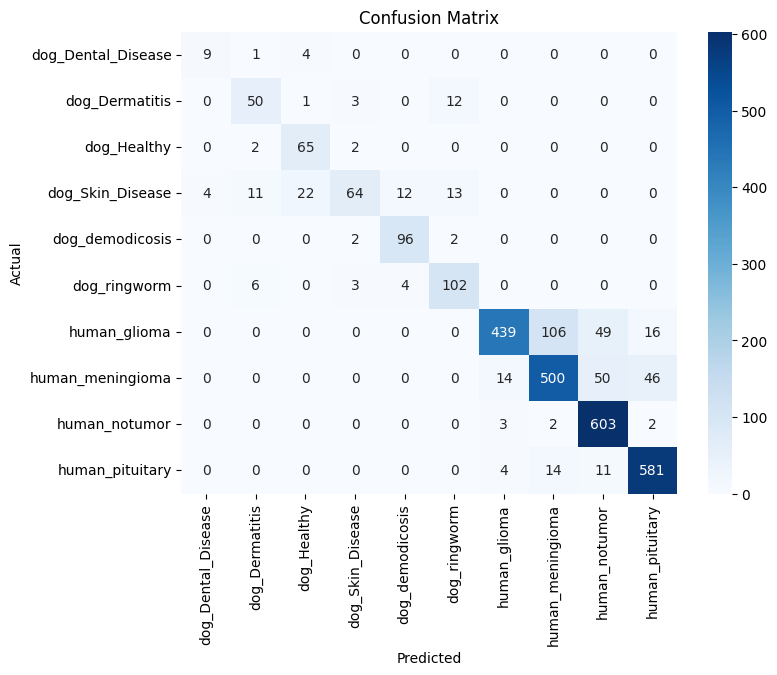

In [16]:
# ================================================
# RESULTS
# ================================================
print("\nClassification Report:\n")

print(classification_report(
    test_labels_filtered,
    pred_labels,
    target_names=unique_labels
))

cm = confusion_matrix(test_labels_filtered, pred_labels)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=unique_labels,
            yticklabels=unique_labels,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

184/184 ━━━━━━━━━━━━━━━━━━━━ 6s 32ms/step
Labels: 2930
Predictions: 2930


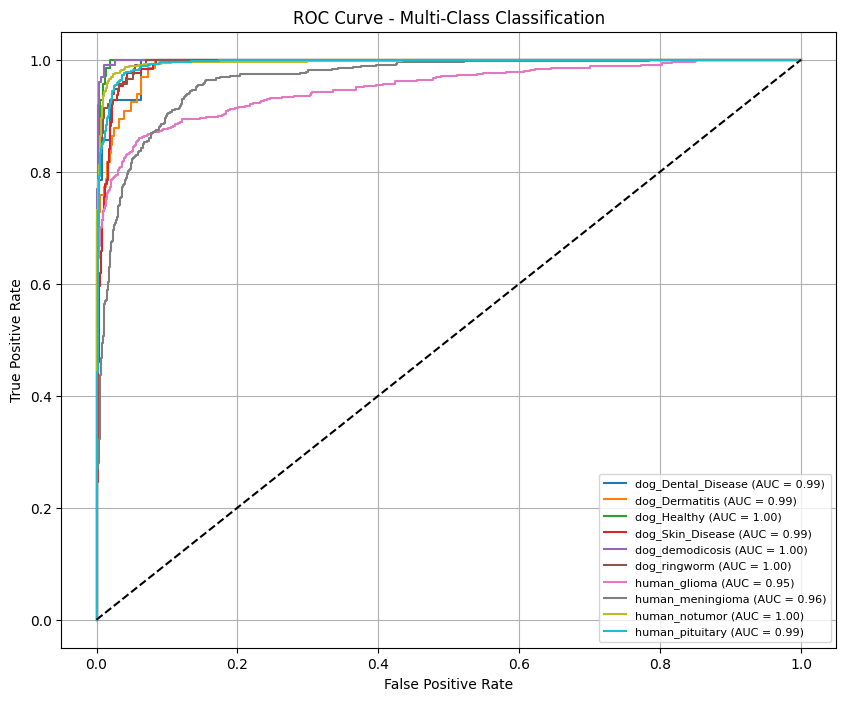

In [17]:
# ==================================================
# ROC CURVE
# ==================================================
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Binarize labels
y_test_bin = label_binarize(
    test_labels_filtered,
    classes=range(len(unique_labels))
)

# Predictions
y_score = model.predict(test_images, batch_size=16)


print("Labels:", len(test_labels_filtered))
print("Predictions:", len(y_score))

# ROC variables
fpr, tpr, roc_auc = {}, {}, {}

plt.figure(figsize=(10, 8))

# Loop through each class
for i in range(len(unique_labels)):

    # Skip if class not present
    if len(np.unique(y_test_bin[:, i])) < 2:
        print(f"Skipping class {unique_labels[i]}")
        continue

    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(
        fpr[i],
        tpr[i],
        label=f"{unique_labels[i]} (AUC = {roc_auc[i]:.2f})"
    )

# Diagonal line
plt.plot([0,1], [0,1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Multi-Class Classification")
plt.legend(loc="lower right", fontsize=8)
plt.grid()

plt.show()

In [18]:
# ====================================================
# SAVE MODEL
# ====================================================
model.save("Multi_Class_Disease_Detection_System.h5")
print("Model Saved 🤖")

Model Saved 🤖
